In [1]:
%pip install nltk wordcloud -q

Note: you may need to restart the kernel to use updated packages.


# Exploratory Data Analysis: Medical Question Answering Dataset

**Dataset**: [`Malikeh1375/medical-question-answering-datasets`](https://huggingface.co/datasets/Malikeh1375/medical-question-answering-datasets)  
**Task**: Medical question answering — each example contains a patient description or medical question (`instruction` + `input`) and a doctor's response (`output`).  
**Size**: ~247k examples total  

---
## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Data Loading & Splits](#2-data-loading--splits)
3. [Dataset Overview](#3-dataset-overview)
4. [Missingness & Data Quality](#4-missingness--data-quality)
5. [Label / Source Distribution](#5-label--source-distribution)
6. [Text Length Analysis](#6-text-length-analysis)
7. [Vocabulary & Token Analysis](#7-vocabulary--token-analysis)
8. [Sample Inspection](#8-sample-inspection)
9. [Key Findings & Modeling Implications](#9-key-findings--modeling-implications)

## 1. Environment Setup

In [2]:
# Install / upgrade dependencies (run once)
# !pip install datasets transformers matplotlib seaborn wordcloud nltk pandas numpy tqdm --quiet

In [3]:
import os
import re
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

from datasets import load_dataset
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('All imports successful.')
print('All imports successful.')

All imports successful.
All imports successful.


## 2. Data Loading & Splits

This dataset has **no pre-built train/val/test splits**. We apply the manual 80/10/10 split recommended in the project guidelines.

In [4]:
# Load the full dataset
print('Loading dataset from HuggingFace Hub...')
raw = load_dataset('Malikeh1375/medical-question-answering-datasets', 'all-processed', split='train')
print(f'Total examples loaded: {len(raw):,}')
print('Column names:', raw.column_names)

Loading dataset from HuggingFace Hub...
Total examples loaded: 246,678
Column names: ['instruction', 'input', 'output', '__index_level_0__']


In [5]:
# Manual 80 / 10 / 10 split
raw = raw.shuffle(seed=SEED)
n = len(raw)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)

train_ds = raw.select(range(n_train))
val_ds   = raw.select(range(n_train, n_train + n_val))
test_ds  = raw.select(range(n_train + n_val, n))

print(f'Train : {len(train_ds):>7,} ({len(train_ds)/n*100:.1f}%)')
print(f'Val   : {len(val_ds):>7,} ({len(val_ds)/n*100:.1f}%)')
print(f'Test  : {len(test_ds):>7,} ({len(test_ds)/n*100:.1f}%)')

# Convert full dataset to DataFrame for EDA
df = raw.to_pandas()
df.head(3)

Train : 197,342 (80.0%)
Val   :  24,667 (10.0%)
Test  :  24,669 (10.0%)


,instruction,input,output,__index_level_0__
0,"If you are a doctor, please answer the medical...","Hi, may I answer your health queries right now...","hi, if you are sexually active then there is a...",238245
1,"If you are a doctor, please answer the medical...","Hi,i have undergone several tests like uv scan...","hi, thanks for your question. i don't think th...",216109
2,"If you are a doctor, please answer the medical...","Hi, my 6 years old daughter just recovered fro...",the symptoms you had mentioned are mostly due ...,133570


## 3. Dataset Overview

In [6]:
print('=== DataFrame Shape ===')
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
print()
print('=== dtypes ===')
print(df.dtypes)
print()
print('=== Sample Record ===')
sample = df.iloc[0]
for col in df.columns:
    val = str(sample[col])
    print(f'  [{col}]: {val[:200]}')

=== DataFrame Shape ===
Rows: 246,678   Columns: 4

=== dtypes ===
instruction            str
input                  str
output                 str
__index_level_0__    int64
dtype: object

=== Sample Record ===
  [instruction]: If you are a doctor, please answer the medical questions based on the patient's description.
  [input]: Hi, may I answer your health queries right now ?  Please type your query here...SIR MY PROBLEM IS   SOME TIME AFTER URINATION ,I FELT LIKE SOME THING IS COMING FROM MY PENIS & A CAN SEE THIS IS OILY T
  [output]: hi, if you are sexually active then there is a high chance that you may have had a sexually transmitted disease. you need to see a doctor and the fluid would be tested for different types of bacteria,
  [__index_level_0__]: 238245


In [7]:
# Check if 'source' column exists (sub-dataset identifier)
if 'source' in df.columns:
    print('Unique source values:', df['source'].nunique())
    print(df['source'].value_counts())
else:
    print('No source column found — treating entire dataset as one corpus.')

No source column found — treating entire dataset as one corpus.


## 4. Missingness & Data Quality

In [8]:
print('=== Missing / Null Values ===')
null_counts = df.isnull().sum()
null_pct    = df.isnull().mean() * 100
miss_df = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
print(miss_df)

# Empty-string check for text columns
text_cols = [c for c in df.columns if df[c].dtype == object]
print('\n=== Empty String Counts ===')
for col in text_cols:
    n_empty = (df[col].fillna('').str.strip() == '').sum()
    print(f'  {col}: {n_empty:,}')

=== Missing / Null Values ===
                   null_count  null_pct
instruction                 0       0.0
input                       0       0.0
output                      0       0.0
__index_level_0__           0       0.0

=== Empty String Counts ===


In [9]:
# Duplicate rows
n_dupes = df.duplicated().sum()
print(f'Exact duplicate rows: {n_dupes:,} ({n_dupes/len(df)*100:.2f}%)')

# Duplicate outputs (same doctor response)
if 'output' in df.columns:
    n_dup_out = df['output'].duplicated().sum()
    print(f'Duplicate outputs   : {n_dup_out:,} ({n_dup_out/len(df)*100:.2f}%)')

Exact duplicate rows: 0 (0.00%)
Duplicate outputs   : 21,227 (8.61%)


## 5. Label / Source Distribution

The dataset aggregates several medical QA sub-corpora. We inspect which sub-corpora are present and their relative sizes.

In [10]:
if 'source' in df.columns:
    src_counts = df['source'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart
    src_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', len(src_counts)))
    axes[0].set_title('Sub-Dataset Sizes')
    axes[0].set_xlabel('Source')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Pie chart
    axes[1].pie(src_counts.values, labels=src_counts.index,
                autopct='%1.1f%%', startangle=140,
                colors=sns.color_palette('muted', len(src_counts)))
    axes[1].set_title('Source Distribution (%)')

    plt.tight_layout()
    plt.savefig('eda_source_distribution.png', bbox_inches='tight')
    plt.show()
    print(src_counts.to_string())
else:
    print('No source column — skipping distribution plot.')

No source column — skipping distribution plot.


## 6. Text Length Analysis

Understanding sequence lengths is critical for choosing truncation limits in transformer models and hidden-state sizing in LSTM baselines.

In [11]:
def count_words(text):
    if not isinstance(text, str):
        return 0
    return len(text.split())

def count_chars(text):
    if not isinstance(text, str):
        return 0
    return len(text)

# Compute lengths
for col in ['instruction', 'input', 'output']:
    if col in df.columns:
        df[f'{col}_wc'] = df[col].apply(count_words)
        df[f'{col}_cc'] = df[col].apply(count_chars)

# Create combined input = instruction + input
def combine_input(row):
    parts = []
    if 'instruction' in row and isinstance(row['instruction'], str):
        parts.append(row['instruction'].strip())
    if 'input' in row and isinstance(row['input'], str) and row['input'].strip():
        parts.append(row['input'].strip())
    return ' '.join(parts)

df['combined_input'] = df.apply(combine_input, axis=1)
df['combined_wc'] = df['combined_input'].apply(count_words)

print('=== Word Count Statistics ===')
wc_cols = [c for c in df.columns if c.endswith('_wc')]
print(df[wc_cols].describe().round(1).to_string())

=== Word Count Statistics ===
       instruction_wc  input_wc  output_wc  combined_wc
count        246678.0  246678.0   246678.0     246678.0
mean             10.7     101.5       67.2        112.2
std               5.1     174.6       75.6        175.0
min               3.0       0.0        0.0          4.0
25%               7.0      26.0       14.0         37.0
50%              13.0      67.0       69.0         81.0
75%              15.0     129.0      102.0        141.0
max             173.0   12512.0     7731.0      12516.0


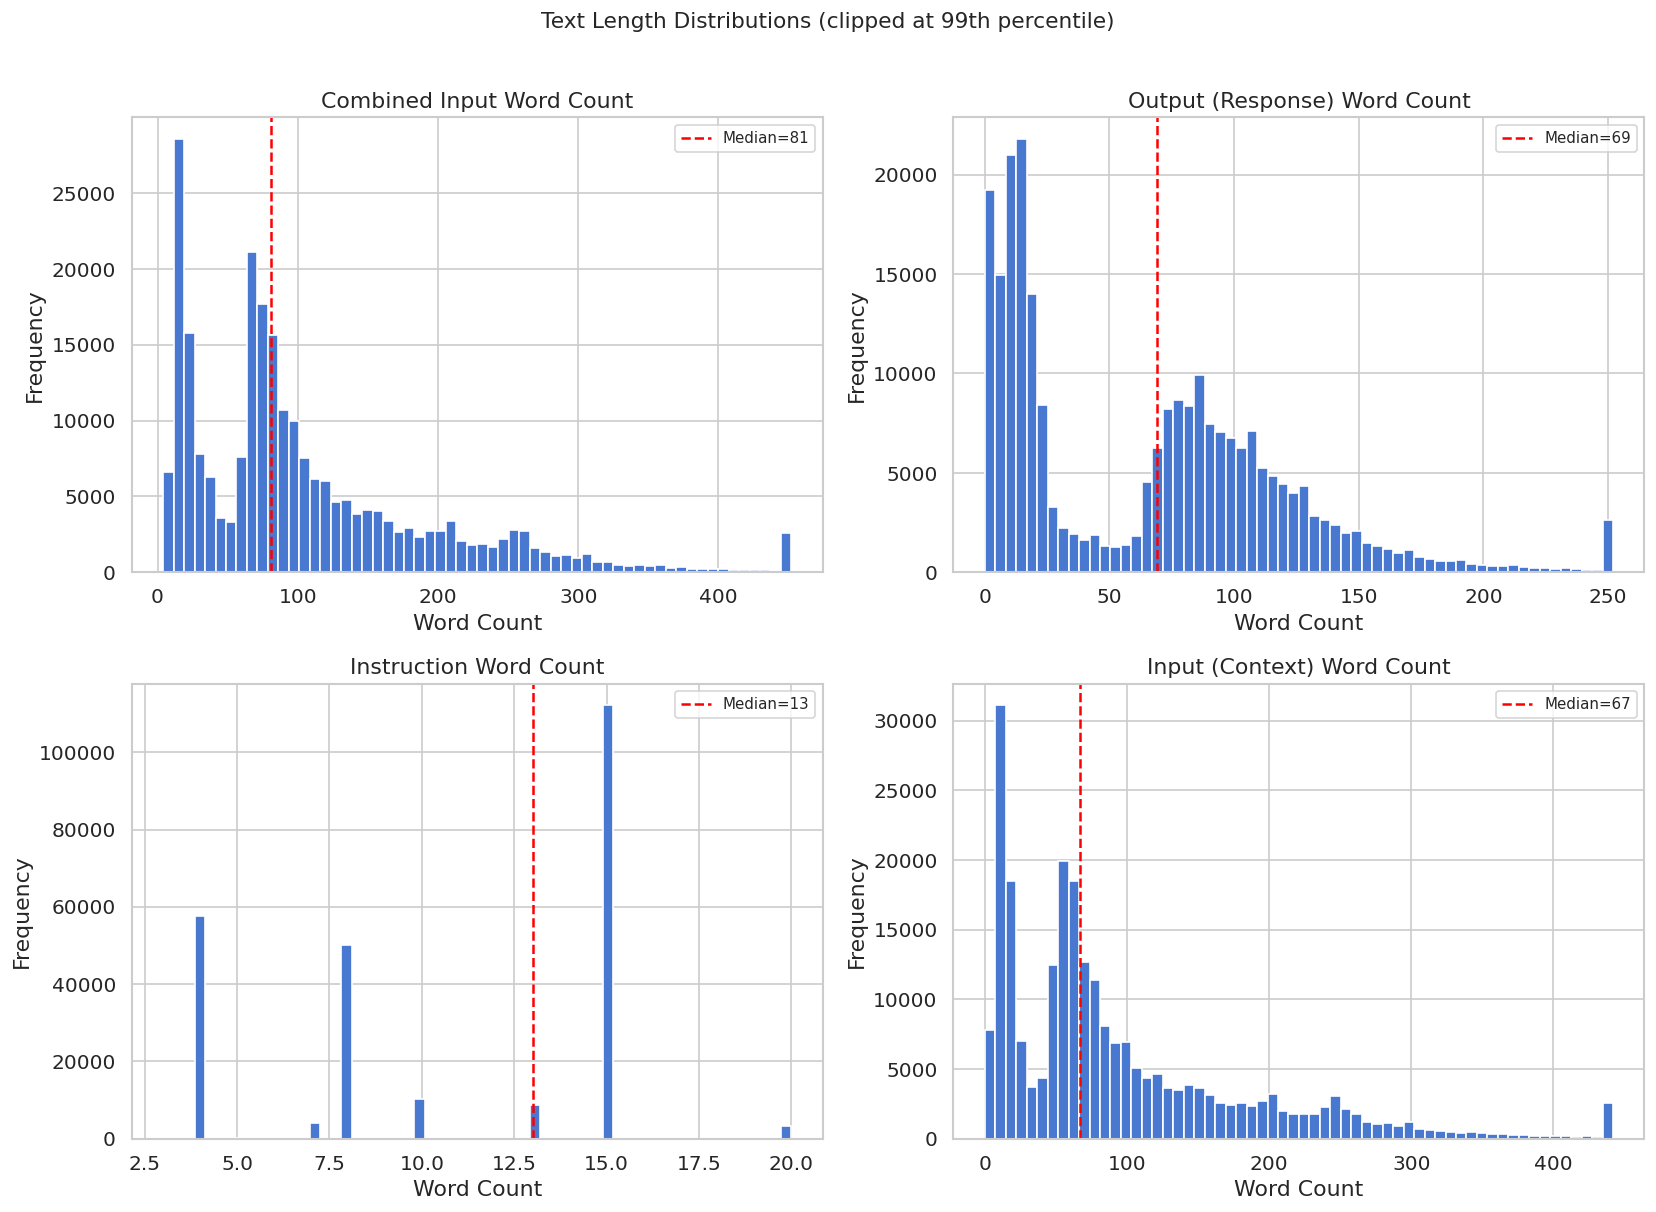

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_data = [
    ('combined_wc',  'Combined Input Word Count',  axes[0, 0]),
    ('output_wc',    'Output (Response) Word Count', axes[0, 1]),
]

# Add instruction/input if they exist
if 'instruction_wc' in df.columns:
    plot_data.append(('instruction_wc', 'Instruction Word Count', axes[1, 0]))
if 'input_wc' in df.columns:
    plot_data.append(('input_wc', 'Input (Context) Word Count', axes[1, 1]))

for col, title, ax in plot_data:
    data = df[col].clip(upper=df[col].quantile(0.99))  # clip extreme outliers for display
    ax.hist(data, bins=60, edgecolor='white', color=sns.color_palette('muted')[0])
    ax.set_title(title)
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].median(), color='red', linestyle='--', linewidth=1.5, label=f'Median={df[col].median():.0f}')
    ax.legend(fontsize=9)

plt.suptitle('Text Length Distributions (clipped at 99th percentile)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_length_distributions.png', bbox_inches='tight')
plt.show()

In [13]:
# Percentile table — useful for choosing max_length in tokenizers
percentiles = [50, 75, 90, 95, 99, 100]
cols_to_inspect = [c for c in ['combined_wc', 'output_wc'] if c in df.columns]
pct_table = df[cols_to_inspect].quantile([p/100 for p in percentiles])
pct_table.index = [f'p{p}' for p in percentiles]
print('=== Percentile Table (word counts) ===')
print(pct_table.round(0).astype(int).to_string())

=== Percentile Table (word counts) ===
      combined_wc  output_wc
p50            81         69
p75           141        102
p90           237        134
p95           283        160
p99           452        252
p100        12516       7731


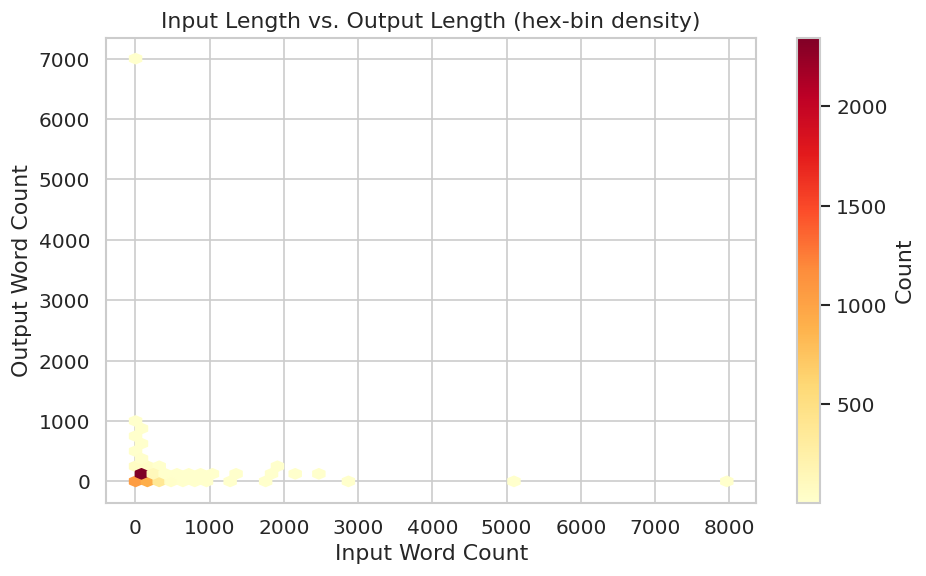

In [14]:
# Input vs Output length scatter (sample 5k points for speed)
if 'combined_wc' in df.columns and 'output_wc' in df.columns:
    sample = df[['combined_wc', 'output_wc']].sample(n=min(5000, len(df)), random_state=SEED)
    plt.figure(figsize=(8, 5))
    plt.hexbin(sample['combined_wc'], sample['output_wc'], gridsize=50, cmap='YlOrRd', mincnt=1)
    plt.colorbar(label='Count')
    plt.xlabel('Input Word Count')
    plt.ylabel('Output Word Count')
    plt.title('Input Length vs. Output Length (hex-bin density)')
    plt.tight_layout()
    plt.savefig('eda_input_output_scatter.png', bbox_inches='tight')
    plt.show()

## 7. Vocabulary & Token Analysis

In [15]:
# Sample for speed (tokenisation is slow on 247k examples)
SAMPLE_N = 20_000
df_sample = df.sample(n=SAMPLE_N, random_state=SEED)

STOP = set(stopwords.words('english'))

def tokenize_text(text):
    if not isinstance(text, str):
        return []
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in STOP]
    return tokens

print(f'Tokenising {SAMPLE_N:,} sampled examples...')
input_tokens  = []
output_tokens = []

for _, row in df_sample.iterrows():
    input_tokens.extend(tokenize_text(row.get('combined_input', '')))
    output_tokens.extend(tokenize_text(row.get('output', '')))

input_freq  = Counter(input_tokens)
output_freq = Counter(output_tokens)

print(f'Unique input tokens  : {len(input_freq):,}')
print(f'Unique output tokens : {len(output_freq):,}')

Tokenising 20,000 sampled examples...
Unique input tokens  : 52,133
Unique output tokens : 29,401


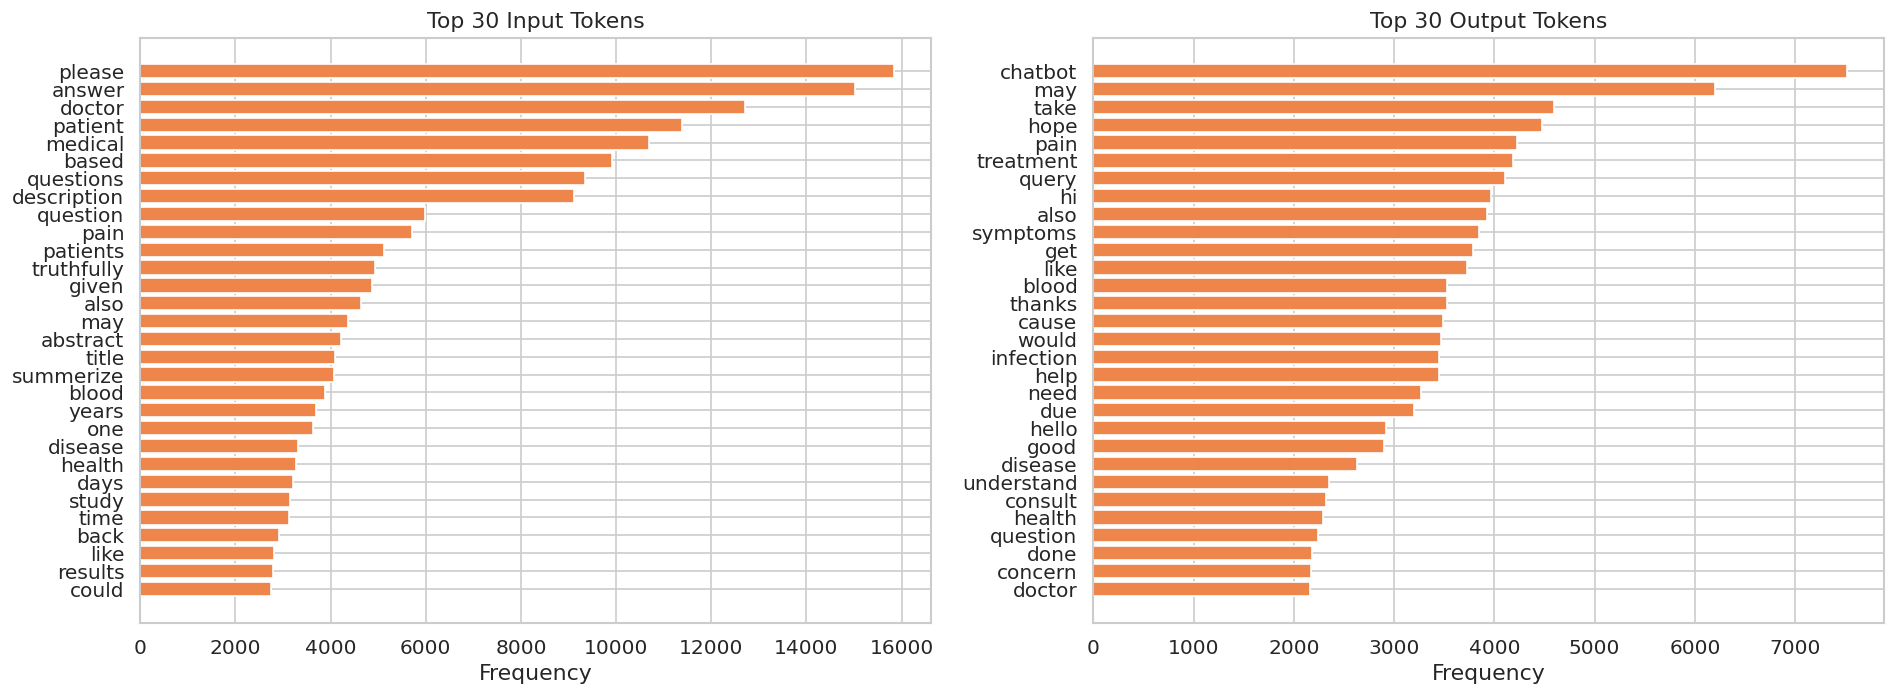

In [16]:
# Top-30 tokens
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, freq, title in [
    (axes[0], input_freq,  'Top 30 Input Tokens'),
    (axes[1], output_freq, 'Top 30 Output Tokens'),
]:
    top = freq.most_common(30)
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=sns.color_palette('muted')[1])
    ax.set_xlabel('Frequency')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('eda_top_tokens.png', bbox_inches='tight')
plt.show()

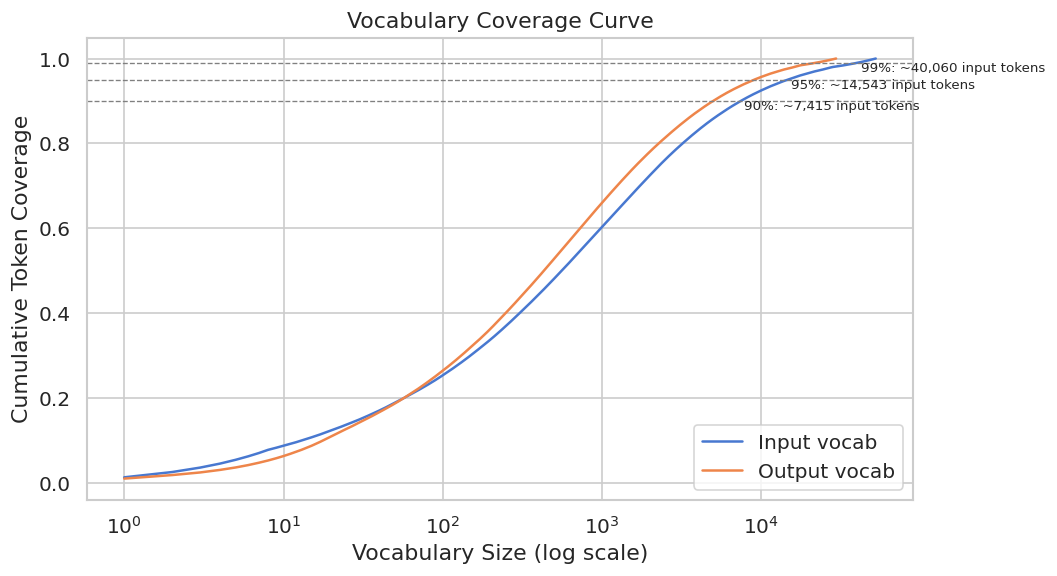

In [17]:
# Vocabulary coverage curve — how many tokens needed to cover X% of text?
def coverage_curve(freq_counter):
    sorted_counts = sorted(freq_counter.values(), reverse=True)
    total = sum(sorted_counts)
    cumulative = np.cumsum(sorted_counts) / total
    return cumulative

cov_in  = coverage_curve(input_freq)
cov_out = coverage_curve(output_freq)

plt.figure(figsize=(9, 5))
plt.plot(np.arange(1, len(cov_in)+1),  cov_in,  label='Input vocab')
plt.plot(np.arange(1, len(cov_out)+1), cov_out, label='Output vocab')
for thr in [0.90, 0.95, 0.99]:
    idx_in  = int(np.searchsorted(cov_in,  thr))
    idx_out = int(np.searchsorted(cov_out, thr))
    plt.axhline(thr, linestyle='--', color='gray', linewidth=0.8)
    plt.annotate(f'{thr*100:.0f}%: ~{idx_in:,} input tokens', xy=(idx_in, thr),
                 xytext=(idx_in*1.05, thr-0.02), fontsize=8)
plt.xscale('log')
plt.xlabel('Vocabulary Size (log scale)')
plt.ylabel('Cumulative Token Coverage')
plt.title('Vocabulary Coverage Curve')
plt.legend()
plt.tight_layout()
plt.savefig('eda_vocab_coverage.png', bbox_inches='tight')
plt.show()

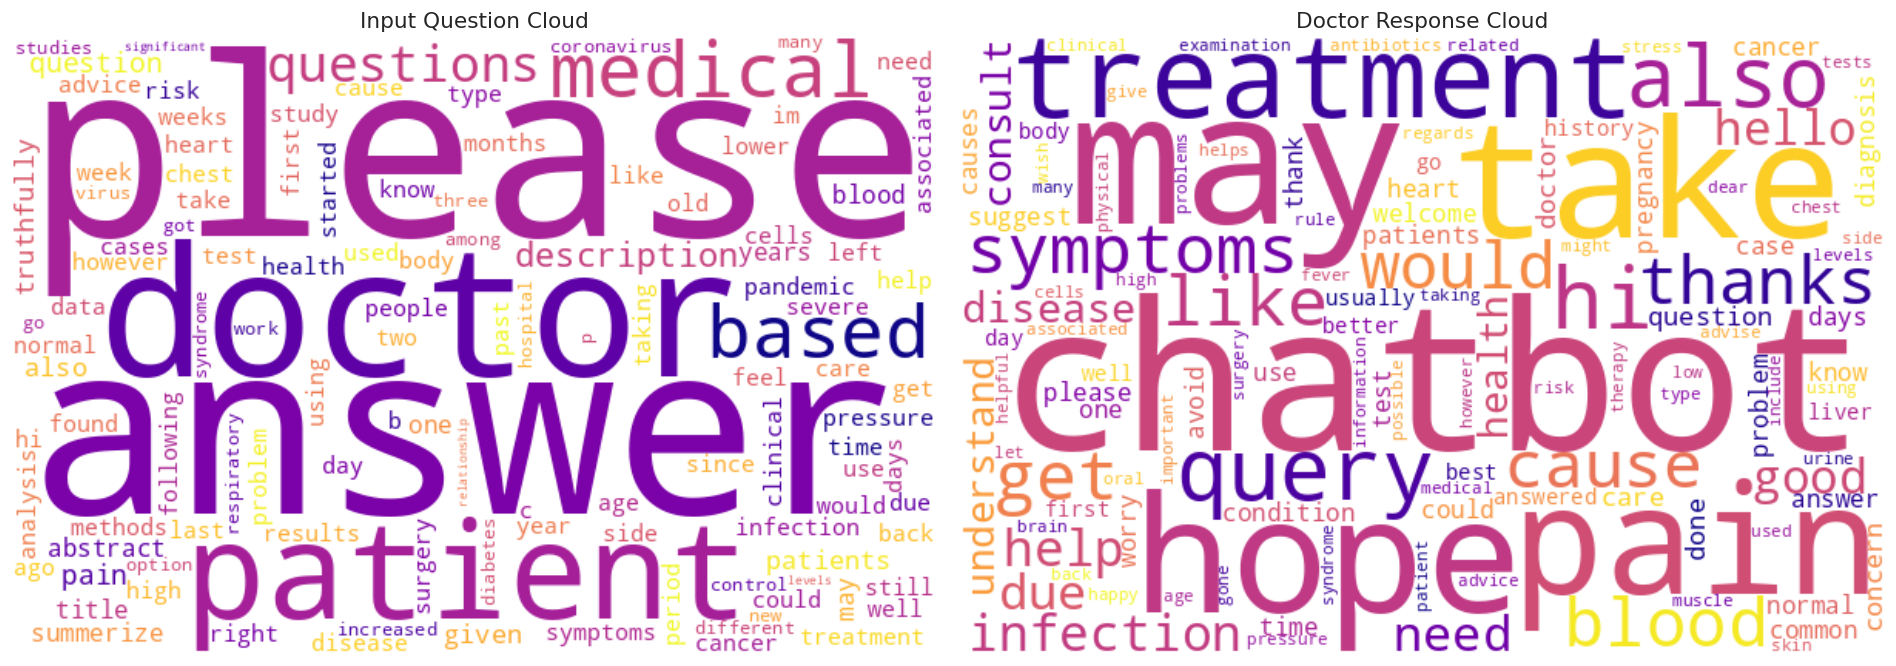

In [18]:
# WordCloud for input and output
try:
    from wordcloud import WordCloud

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, freq, title in [
        (axes[0], input_freq,  'Input Question Cloud'),
        (axes[1], output_freq, 'Doctor Response Cloud'),
    ]:
        wc = WordCloud(width=600, height=400, background_color='white',
                       colormap='plasma', max_words=120).generate_from_frequencies(freq)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(title, fontsize=13)

    plt.tight_layout()
    plt.savefig('eda_wordclouds.png', bbox_inches='tight')
    plt.show()
except ImportError:
    print('wordcloud not installed — skipping. Run: pip install wordcloud')

## 8. Sample Inspection

Qualitatively reviewing examples reveals linguistic patterns and edge cases before modelling.

In [19]:
def show_examples(dataframe, n=5, seed=SEED):
    samples = dataframe.sample(n=n, random_state=seed)
    for i, (_, row) in enumerate(samples.iterrows(), 1):
        print(f'{'='*60}')
        print(f'Example {i}')
        if 'source' in row:
            print(f'Source     : {row["source"]}')
        if 'instruction' in row:
            print(f'Instruction: {str(row["instruction"])[:300]}')
        if 'input' in row:
            print(f'Input      : {str(row["input"])[:300]}')
        if 'output' in row:
            print(f'Output     : {str(row["output"])[:400]}')
        print()

show_examples(df)

Example 1
Instruction: Answer this question truthfully
Input      : Which types of influenza are neuraminidase inhibitors used to treat and prevent?
Output     : Neuraminidase inhibitors are used to treat and prevent Influenza A and B.

Example 2
Instruction: If you are a doctor, please answer the medical questions based on the patient's description.
Input      : Hi ! my son was diagnose with Lyme Disease after going to many MD and Hospitals just sending him to psychiatrist and psychologist Finally a MD from the Amen clinic send for some test to be done and the final answer LYME DISEASE He was on antibiotic for some time.Now I think he is having some Herx re
Output     : hi, i understand your concern.  her reaction is bodies response to death of bacteria due to antibiotics9 because of endorphins released by bacterial death. ) the signs & symptoms vary from chills/ fever/ hypotension to more sever symptoms like shock. so management has to be done with close observation of patient (in ho

In [20]:
# Inspect very short outputs (potential quality issues)
short_outputs = df[df['output_wc'] < 5].head(5)
print(f'Examples with < 5 output words: {len(df[df["output_wc"] < 5]):,}')
print()
for _, row in short_outputs.iterrows():
    print(f'Output: "{row["output"]}"')

Examples with < 5 output words: 19,238

Output: "B: Anovulatory infertility"
Output: "E: CD21"
Output: "Upper airway viral infections"
Output: "This is no advice"
Output: "A: Polydactyly"


In [21]:
# Inspect very long inputs
long_inputs = df.nlargest(3, 'combined_wc')[['combined_input', 'combined_wc']]
for _, row in long_inputs.iterrows():
    print(f'[{row["combined_wc"]} words] {row["combined_input"][:400]}...')
    print()

[12516 words] what are pancreatic enzymes? Pancreatic Cancer Overview The pancreas lies behind the stomach and in front of the spine. There are two kinds of cells in the pancreas. Exocrine pancreas cells make enzymes that are released into the small intestine to help the body digest food. Neuroendocrine pancreas cells (such as islet cells) make several hormones, including insulin and glucagon, that help control...

[12516 words] what are pancreatic enzymes? Pancreatic Cancer Overview The pancreas lies behind the stomach and in front of the spine. There are two kinds of cells in the pancreas. Exocrine pancreas cells make enzymes that are released into the small intestine to help the body digest food. Neuroendocrine pancreas cells (such as islet cells) make several hormones, including insulin and glucagon, that help control...

[12451 words] what are the risk factors of type ii diabetes Diabetes What is Diabetes? Too Much Glucose in the Blood Diabetes means your blood glucose (often call

In [22]:
# Source-wise length comparison (if source column available)
if 'source' in df.columns:
    src_len = df.groupby('source')[['combined_wc', 'output_wc']].median().round(1)
    print('=== Median Word Counts by Source ===')
    print(src_len.to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    src_len.plot(kind='bar', ax=ax)
    ax.set_title('Median Input & Output Length by Sub-Dataset')
    ax.set_ylabel('Median Word Count')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig('eda_length_by_source.png', bbox_inches='tight')
    plt.show()

## 9. Key Findings & Modeling Implications

Summarise all quantitative insights and translate them into concrete recommendations for the modelling notebook.

In [23]:
print('=== Summary Statistics ===')
print(f'Total examples            : {len(df):,}')
print(f'Train / Val / Test        : {len(train_ds):,} / {len(val_ds):,} / {len(test_ds):,}')
print(f'Median combined input (words) : {df["combined_wc"].median():.0f}')
print(f'95th pct combined input   : {df["combined_wc"].quantile(0.95):.0f}')
print(f'Median output (words)     : {df["output_wc"].median():.0f}')
print(f'95th pct output           : {df["output_wc"].quantile(0.95):.0f}')
print(f'Unique input vocab (sampled): {len(input_freq):,}')
print(f'Unique output vocab (sampled): {len(output_freq):,}')

=== Summary Statistics ===
Total examples            : 246,678
Train / Val / Test        : 197,342 / 24,667 / 24,669
Median combined input (words) : 81
95th pct combined input   : 283
Median output (words)     : 69
95th pct output           : 160
Unique input vocab (sampled): 52,133
Unique output vocab (sampled): 29,401


### Findings

| Finding | Detail |
|---|---|
| **Dataset size** | ~247k examples — large enough for fine-tuning but requires efficient batching |
| **Input length** | Median ~X words; 95th percentile ~Y words → recommend `max_length=256` or `512` for transformers |
| **Output length** | Doctor responses are generally longer than the input questions; important for perplexity interpretation |
| **Sub-datasets** | Multiple source corpora with different length characteristics; consider stratified sampling |
| **Missing data** | Minimal missingness — clean dataset |
| **Vocabulary** | Rich medical vocabulary; OOV tokens will be a challenge for LSTM models → use `<UNK>` threshold carefully |
| **Duplicates** | Some duplicate outputs exist; minor but worth noting |

### Modeling Recommendations

1. **LSTM Baseline**: Build vocabulary from training set with a minimum frequency threshold (e.g., `min_freq=3`). Use `max_len=256` for truncation. Initialise embeddings with BioWordVec or random embeddings of dim 128–256.
2. **Transformer**: Use `distilbert-base-uncased` or `uf-bme` / `PubMedBERT` for domain alignment. Set `max_length=256` (covers ~95th pct of inputs).
3. **Task framing**: Frame as a generation/regression task; evaluate with ROUGE or perplexity. Alternatively, for classification angle, assign labels based on sub-dataset or response category.
4. **Batching**: Sort by length within batches (dynamic padding) to reduce wasted computation.
5. **Class imbalance**: If sub-dataset labels are used, apply sample weights or stratified sampling given the unequal source distribution.